# Car Sales Data — Exploratory Data Analysis

**Dataset:** `Car_sales.csv`  
**Goal:** Explore the structure of car sales data, understand numerical distributions, identify correlations with price, and extract insights about manufacturer and horsepower trends.

---

## 📋 Table of Contents
1. [Import Libraries](#1)
2. [Load & Preview Data](#2)
3. [Data Cleaning](#3)
4. [Descriptive Statistics](#4)
5. [Min / Max Value Explorer](#5)
6. [Univariate Analysis — Numerical Features](#6)
7. [Manufacturer Distribution](#7)
8. [Correlation Analysis](#8)

---
## 1. Import Libraries <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## 2. Load & Preview Data <a id='2'></a>

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Shontu72/python_data-science-learning__-/main/DATA/Car_sales.csv')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Shape: 157 rows × 16 columns


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
5,Audi,A6,18.780,23.555,Passenger,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,8/9/2011,84.565105
6,Audi,A8,1.380,39.000,Passenger,62.00,4.2,310.0,113.0,74.0,198.2,3.902,23.7,21.0,2/27/2012,134.656858
7,BMW,323i,19.747,NaN,Passenger,26.99,2.5,170.0,107.3,68.4,176.0,3.179,16.6,26.0,6/28/2011,71.191207
8,BMW,328i,9.231,28.675,Passenger,33.40,2.8,193.0,107.3,68.5,176.0,3.197,16.6,24.0,1/29/2012,81.877069
9,BMW,528i,17.527,36.125,Passenger,38.90,2.8,193.0,111.4,70.9,188.0,3.472,18.5,25.0,4/4/2011,83.998724


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-null    flo

---
## 3. Data Cleaning <a id='3'></a>

Steps:
- Standardize column names (replace spaces with underscores)
- Drop duplicates
- Drop uninformative columns
- Inspect missing values

In [5]:
# Standardize column names — replace spaces with underscores
# Applied early so all subsequent code uses consistent naming
df.columns = df.columns.str.replace(' ', '_')
print("Columns:", df.columns.tolist())

Columns: ['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value', 'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor']


In [6]:
# Remove duplicate rows
before = df.shape[0]
df.drop_duplicates(keep='last', inplace=True)
after = df.shape[0]
print(f"Duplicates removed: {before - after} rows  ({before} → {after})")

Duplicates removed: 0 rows  (157 → 157)


In [7]:
# Drop 'Vehicle_type' — low information content for this analysis
df.drop('Vehicle_type', axis=1, inplace=True)
print(f"Remaining columns ({len(df.columns)}): {df.columns.tolist()}")

Remaining columns (15): ['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value', 'Price_in_thousands', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor']


In [8]:
# Check missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
__year_resale_value    36
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Power_perf_factor       2
dtype: int64


In [9]:
# View the exact rows that contain missing values
df.loc[df.isnull().any(axis=1)]

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
2,Acura,CL,14.114,18.225,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
7,BMW,323i,19.747,NaN,26.990,2.5,170.0,107.3,68.4,176.0,3.179,16.6,26.0,6/28/2011,71.191207
15,Cadillac,Seville,15.943,27.100,44.475,4.6,275.0,112.2,75.0,201.0,NaN,18.5,22.0,4/29/2011,115.621358
18,Cadillac,Escalade,14.785,NaN,46.225,5.7,255.0,117.5,77.0,201.2,5.572,30.0,15.0,4/17/2012,109.509117
27,Chevrolet,Impala,107.995,NaN,18.890,3.4,180.0,110.5,73.0,200.0,3.389,17.0,27.0,6/18/2011,71.838039
33,Chrysler,Town & Country,53.480,19.540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7/13/2011,NaN
34,Chrysler,300M,30.696,NaN,29.185,3.5,253.0,113.0,74.4,197.8,3.567,17.0,23.0,2/10/2012,101.655244
38,Dodge,Intrepid,88.028,12.275,22.505,2.7,202.0,113.0,74.7,203.7,3.489,17.0,NaN,6/2/2012,80.831470
44,Dodge,Durango,101.323,NaN,26.310,5.2,230.0,115.7,71.7,193.5,4.394,25.0,17.0,6/27/2012,92.854125
50,Ford,Focus,175.670,NaN,12.315,2.0,107.0,103.0,66.9,174.8,2.564,13.2,30.0,7/22/2012,43.117132


---
## 4. Descriptive Statistics <a id='4'></a>

Summary statistics for all numerical columns.

In [10]:
df.describe().round(2)

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.00,121.00,155.00,156.00,156.00,156.00,156.00,156.00,155.00,156.00,154.00,155.00
mean,53.00,18.07,27.39,3.06,185.95,107.49,71.15,187.34,3.38,17.95,23.84,77.04
std,68.03,11.45,14.35,1.04,56.70,7.64,3.45,13.43,0.63,3.89,4.28,25.14
min,0.11,5.16,9.24,1.00,55.00,92.60,62.60,149.40,1.90,10.30,15.00,23.28
25%,14.11,11.26,18.02,2.30,149.50,103.00,68.40,177.58,2.97,15.80,21.00,60.41
50%,29.45,14.18,22.80,3.00,177.50,107.00,70.55,187.90,3.34,17.20,24.00,72.03
75%,67.96,19.88,31.95,3.58,215.00,112.20,73.43,196.12,3.80,19.58,26.00,89.41
max,540.56,67.55,85.50,8.00,450.00,138.70,79.90,224.50,5.57,32.00,45.00,188.14


In [11]:
# Top 9 cars sorted by fuel efficiency
df.sort_values(by='Fuel_efficiency', ascending=False).head(9)

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
26,Chevrolet,Metro,21.855,5.160,9.235,1.0,55.0,93.1,62.6,149.4,1.895,10.3,45.0,4/13/2012,23.276272
25,Chevrolet,Prizm,32.299,9.125,13.960,1.8,120.0,97.1,66.7,174.3,2.398,13.2,33.0,9/11/2011,48.297636
129,Saturn,SL,80.620,9.200,10.685,1.9,100.0,102.4,66.4,176.9,2.332,12.1,33.0,8/16/2012,39.986425
136,Toyota,Corolla,142.535,10.025,13.108,1.8,120.0,97.0,66.7,174.0,2.420,13.2,33.0,4/11/2011,47.968972
130,Saturn,SC,24.546,10.590,12.535,1.9,100.0,102.4,66.4,180.0,2.367,12.1,33.0,3/16/2011,40.700072
57,Honda,Civic,199.685,9.850,12.885,1.6,106.0,103.2,67.1,175.1,2.339,11.9,32.0,10/21/2011,42.879097
139,Toyota,Celica,33.269,15.445,16.875,1.8,140.0,102.4,68.3,170.5,2.425,14.5,31.0,12/29/2012,56.496030
62,Hyundai,Accent,41.184,5.860,9.699,1.5,92.0,96.1,65.7,166.7,2.240,11.9,31.0,9/10/2012,36.672284
131,Saturn,SW,5.223,10.790,14.290,1.9,124.0,102.4,66.4,176.9,2.452,12.1,31.0,1/15/2011,49.865774


---
## 5. Min / Max Value Explorer <a id='5'></a>

This reusable function returns the rows with the highest and lowest values for any given column — useful for quickly spotting extremes.

In [12]:
def max_min_val(col):
    """
    Returns a side-by-side DataFrame of the max and min
    observations for the given column.

    Parameters
    ----------
    col : str — column name to evaluate

    Returns
    -------
    pd.DataFrame — two-column DataFrame (max | min)
    """
    max_idx = df[col].idxmax()
    min_idx = df[col].idxmin()

    max_obs = pd.DataFrame(df.loc[max_idx]).rename(columns={max_idx: 'MAX'})
    min_obs = pd.DataFrame(df.loc[min_idx]).rename(columns={min_idx: 'MIN'})

    return pd.concat([max_obs, min_obs], axis=1)

In [13]:
# Which car had the highest and lowest sales?
max_min_val('Sales_in_thousands')

,MAX,MIN
Manufacturer,Ford,Mitsubishi
Model,F-Series,3000GT
Sales_in_thousands,540.561,0.11
__year_resale_value,15.075,20.94
Price_in_thousands,26.935,25.45
Engine_size,4.6,3.0
Horsepower,220.0,161.0
Wheelbase,138.5,97.2
Width,79.1,72.4
Length,224.5,180.3


In [14]:
# Which car was the most and least expensive?
max_min_val('Price_in_thousands')

,MAX,MIN
Manufacturer,Mercedes-B,Chevrolet
Model,CL500,Metro
Sales_in_thousands,0.954,21.855
__year_resale_value,NaN,5.16
Price_in_thousands,85.5,9.235
Engine_size,5.0,1.0
Horsepower,302.0,55.0
Wheelbase,113.6,93.1
Width,73.1,62.6
Length,196.6,149.4


---
## 6. Univariate Analysis — Numerical Features <a id='6'></a>

We examine individual numerical distributions. First, a focused look at `Horsepower`, then all numeric columns together.

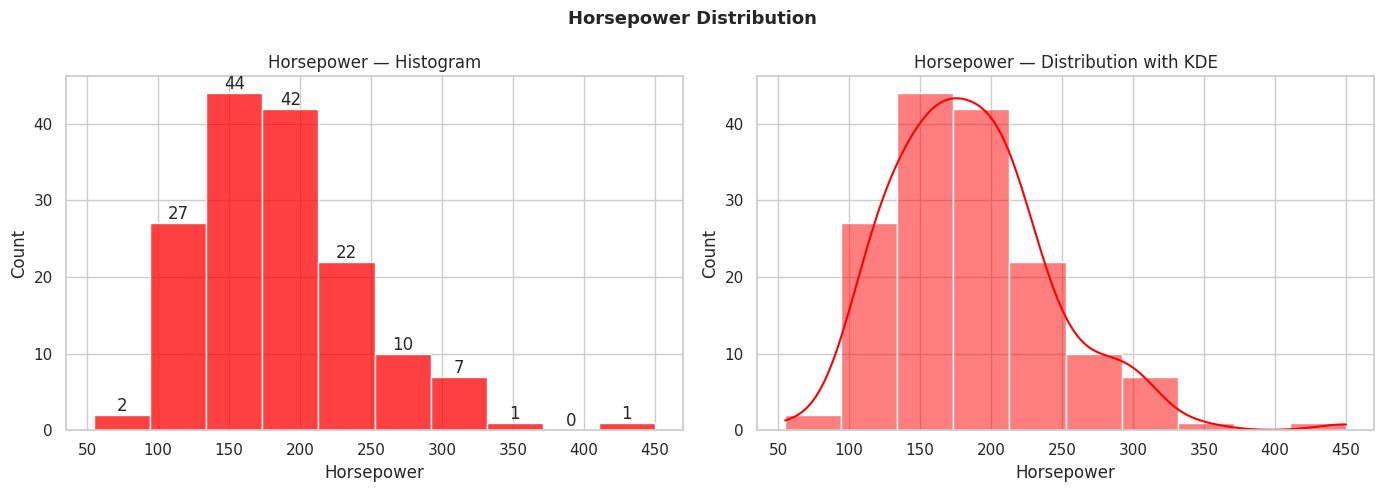

In [15]:
# Horsepower distribution — histogram with KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.histplot(x='Horsepower', data=df, bins=10, color='red', ax=axes[0])
ax.grid(True)
for container in ax.containers:
    ax.bar_label(container)
axes[0].set_title('Horsepower — Histogram')
axes[0].set_xlabel('Horsepower')

sns.histplot(df['Horsepower'].dropna(), kde=True, bins=10, color='red', ax=axes[1])
axes[1].set_title('Horsepower — Distribution with KDE')
axes[1].set_xlabel('Horsepower')

plt.suptitle('Horsepower Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

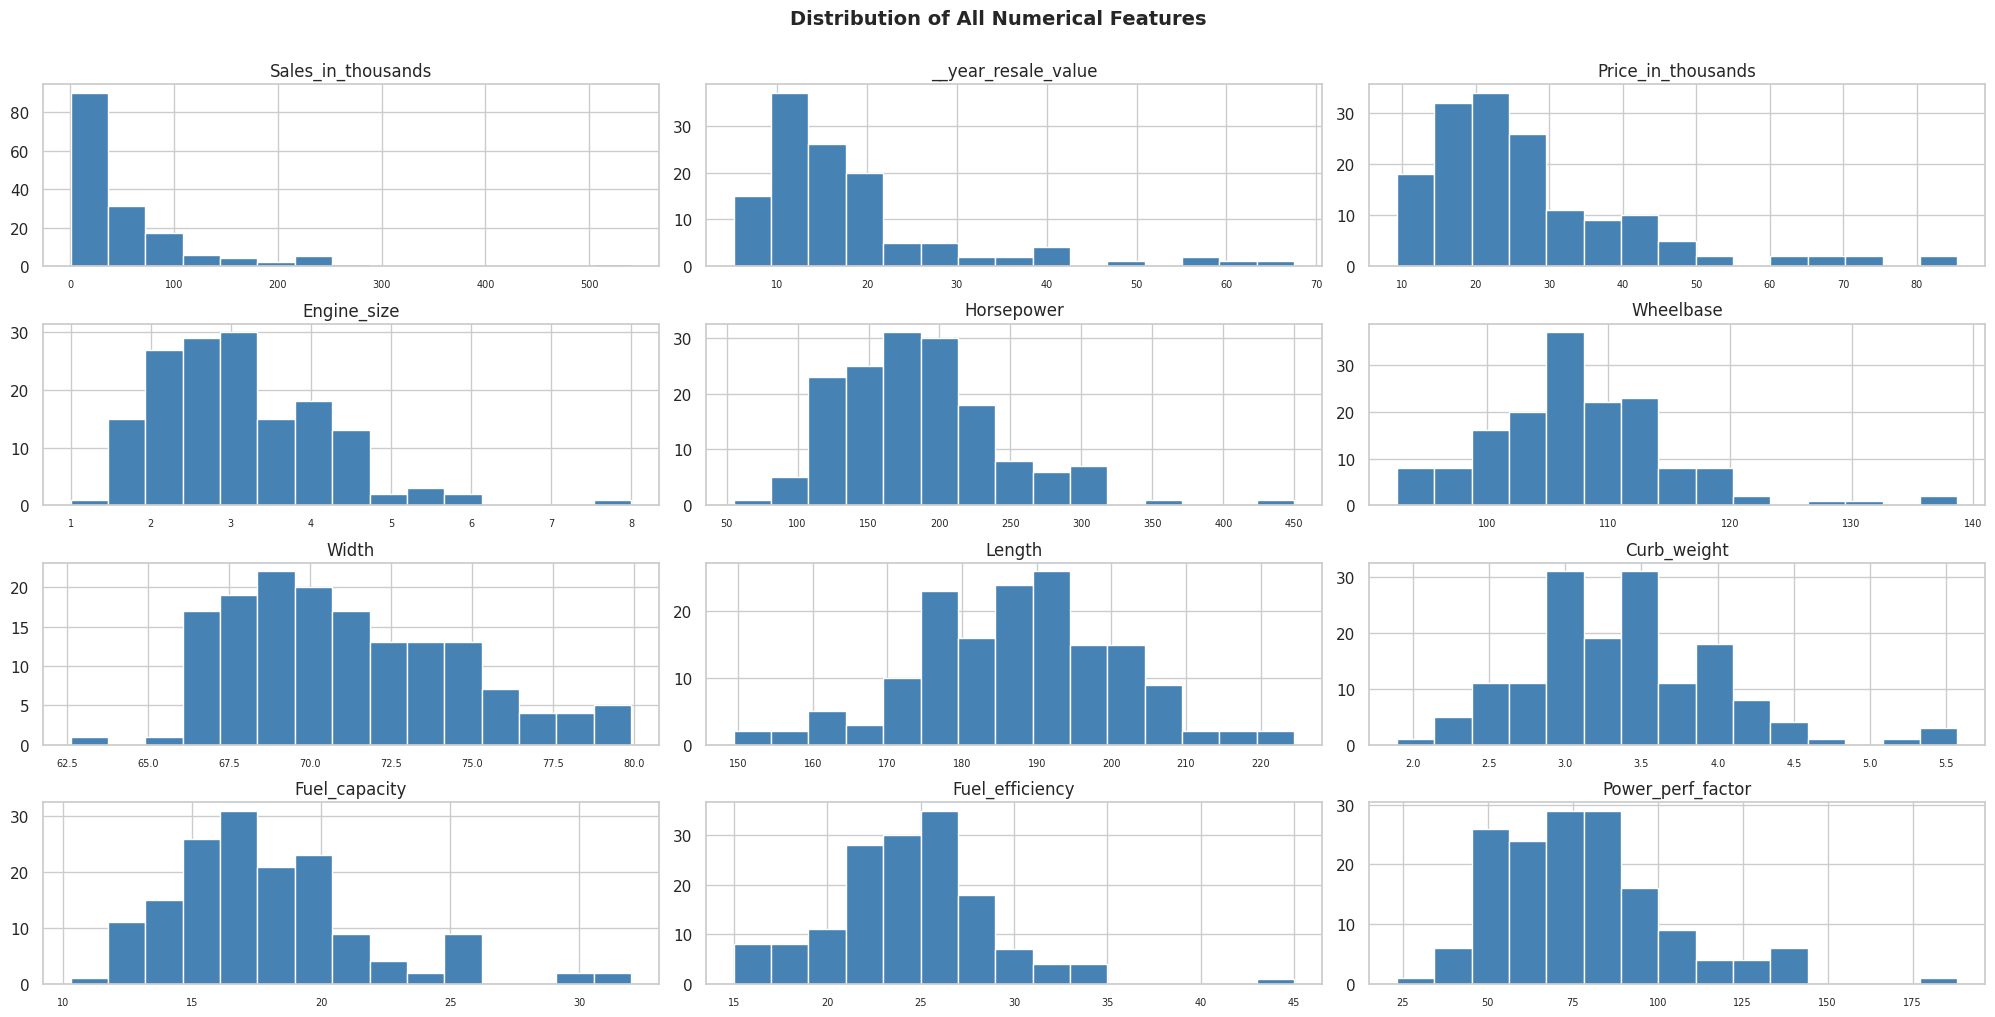

In [16]:
# Histogram overview of all numerical columns
df_num = df.select_dtypes(include=['float64', 'int64'])

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['figure.figsize'] = (20, 10)

df_num.hist(bins=15, xlabelsize=7, color='steelblue', edgecolor='white')
plt.suptitle('Distribution of All Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Reset to default figure size for remaining plots
plt.rcParams['figure.figsize'] = (10, 5)

---
## 7. Manufacturer Distribution <a id='7'></a>

How many car models does each manufacturer have in the dataset?

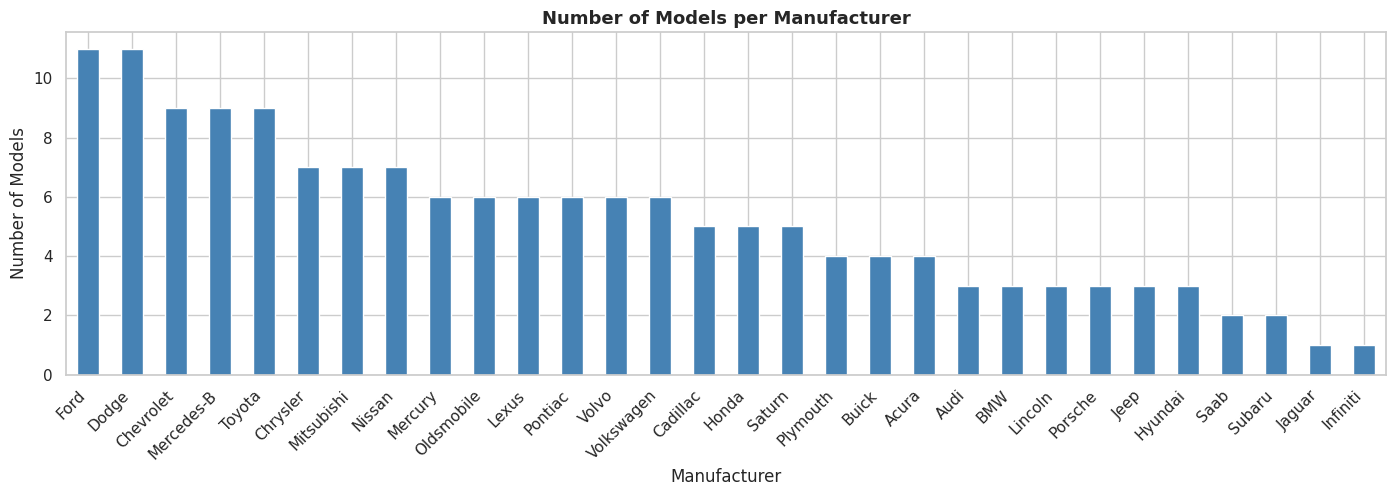

In [17]:
make_dist = df.groupby('Manufacturer').size().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
make_dist.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Models per Manufacturer', fontsize=13, fontweight='bold')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 8. Correlation Analysis <a id='8'></a>

We investigate which features are most correlated with `Price_in_thousands` using pairplots and a filtered heatmap.

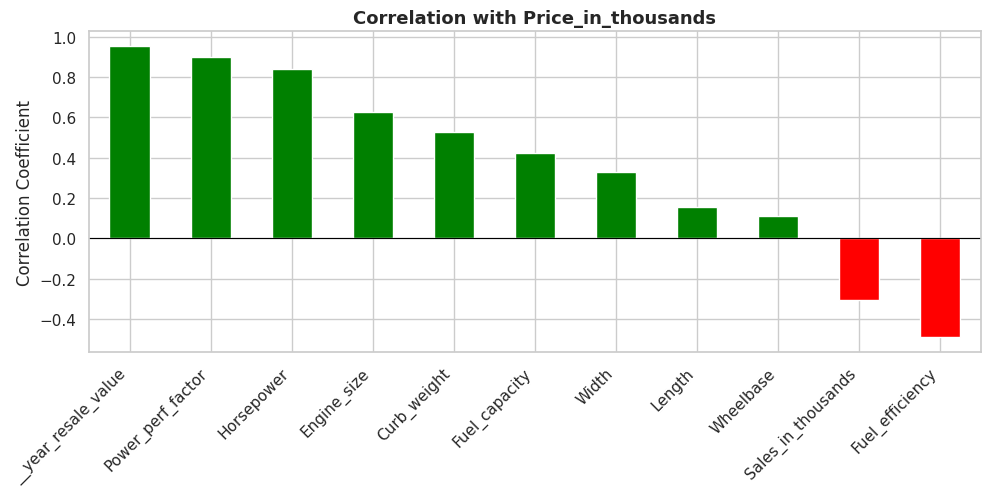

__year_resale_value    0.953840
Power_perf_factor      0.897945
Horsepower             0.839744
Engine_size            0.626875
Curb_weight            0.526224
Fuel_capacity          0.423282
Width                  0.329136
Length                 0.156935
Wheelbase              0.110513
Sales_in_thousands    -0.304734
Fuel_efficiency       -0.492157
Name: Price_in_thousands, dtype: float64


In [18]:
# Correlation of all numerical features with Price
df_corr = df_num.corr()['Price_in_thousands'].drop('Price_in_thousands').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
df_corr.plot(kind='bar', color=['green' if v > 0 else 'red' for v in df_corr], edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Correlation with Price_in_thousands', fontsize=13, fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df_corr)

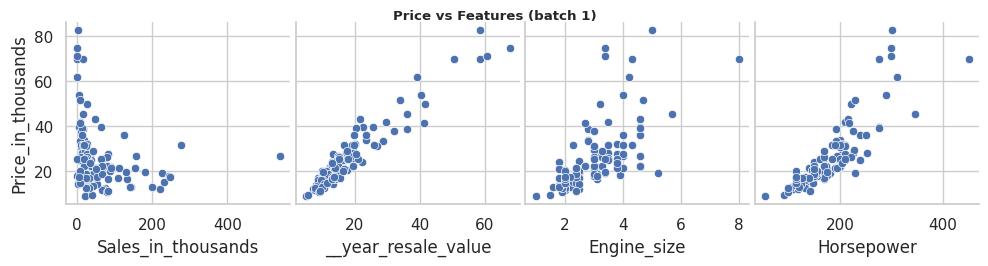

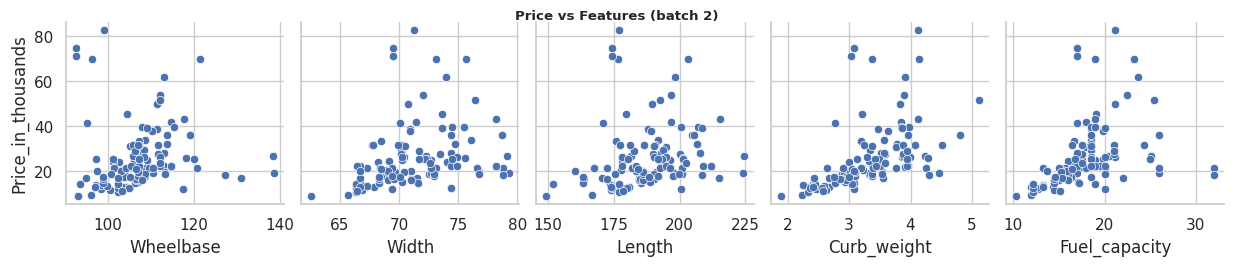

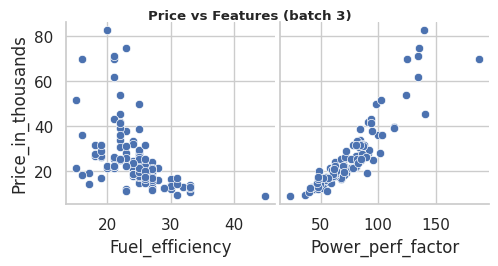

In [19]:
# Pairplots — Price vs all other numerical features (batched 5 at a time)
cols = df_num.columns.tolist()
for i in range(0, len(cols), 5):
    batch = [c for c in cols[i:i+5] if c != 'Price_in_thousands']
    if batch:
        sns.pairplot(df_num.dropna(), y_vars='Price_in_thousands', x_vars=batch)
        plt.suptitle(f'Price vs Features (batch {i//5 + 1})', y=1.02, fontweight='bold')
        plt.show()

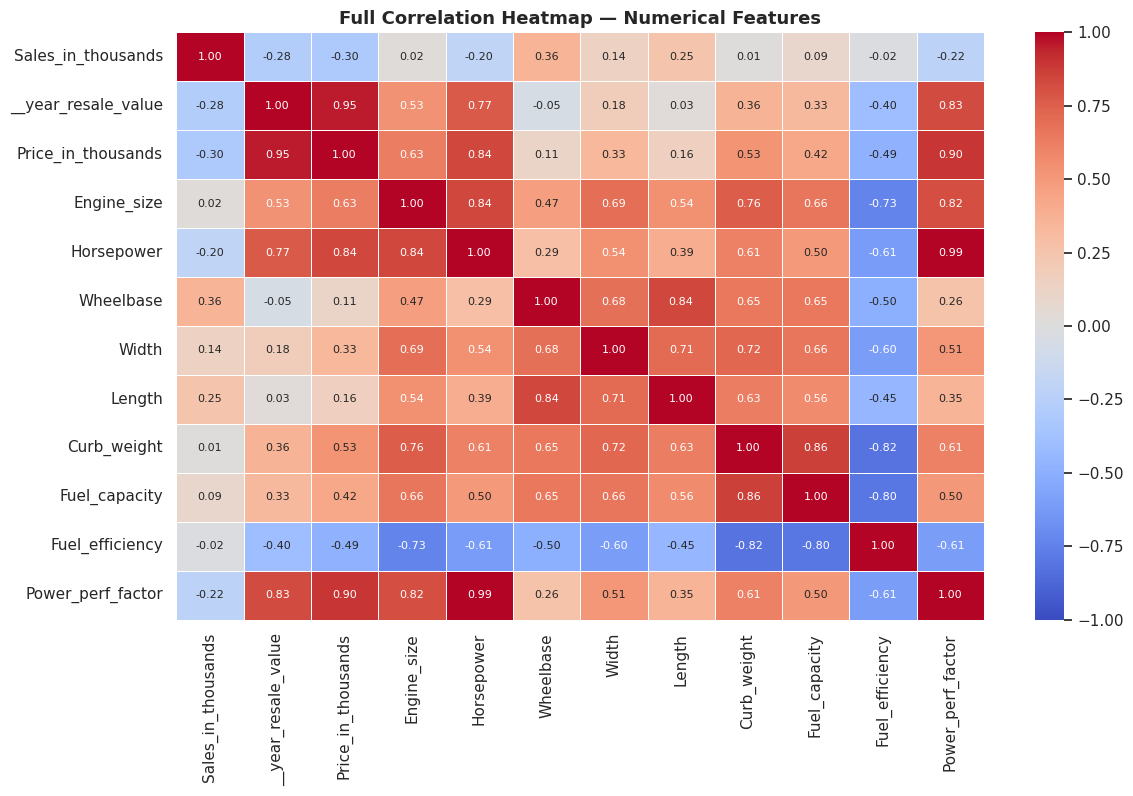

In [20]:
# Full correlation heatmap (all numerical features)
corr = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1.0, vmax=1.0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Full Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

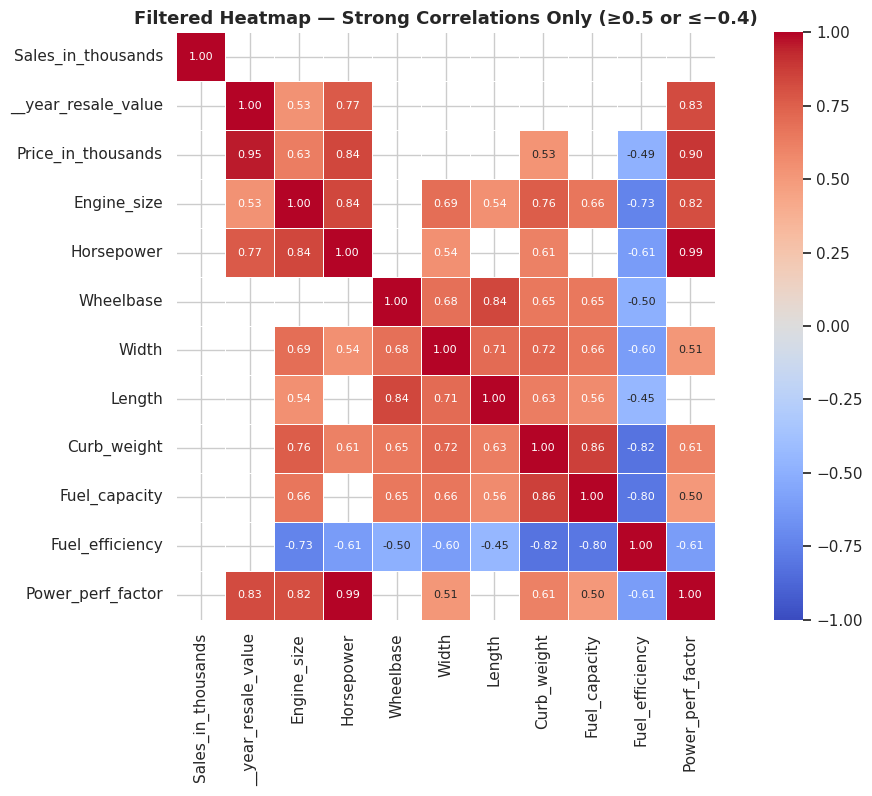

In [21]:
# Filtered heatmap — show only strong correlations (≥ 0.5 or ≤ -0.4)
# Reduces visual noise and highlights the most important relationships
corr_filtered = corr.drop('Price_in_thousands', axis=1)
mask = ~((corr_filtered >= 0.5) | (corr_filtered <= -0.4))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_filtered, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1.0, vmax=1.0, linewidths=0.5, square=True, annot_kws={'size': 8})
plt.title('Filtered Heatmap — Strong Correlations Only (≥0.5 or ≤−0.4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Key Findings

| # | Insight | Detail |
|---|---|---|
| 1 | **Right-skewed pricing** | Most cars are in the lower price range with a few high-value outliers |
| 2 | **Horsepower correlates with price** | Positive correlation — more powerful cars tend to cost more |
| 3 | **Fuel efficiency vs power trade-off** | Negative correlation between horsepower and fuel efficiency |
| 4 | **Manufacturer model count varies** | Some manufacturers have significantly more models represented |
| 5 | **Missing values exist** | A small number of rows have NaN in numerical columns — worth noting for any downstream modeling |

---